# <u>Netflix Content Analysis EDA</u>
## Objective : 
The objective of this project is to perform exploratory data analysis on Netflix's content catalog to identify patterns and trends related to movies, TV shows, content ratings, genres, countries of origin, and release years. The project aims to derive meaningful business insights that can help understand content distribution and growth trends on the platform using Python, Pandas, NumPy, Matplotlib, and Seaborn.

## Disclaimer: 
The dataset used in this project contains Netflix content information up to 2021. All trends and insights are limited to the data available during that period and may not accurately represent Netflix's current content library.

## Importing necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the data

In [2]:
df = pd.read_csv("../data/netflix_dataset.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Exploring the data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
df["type"].unique()

array(['Movie', 'TV Show'], dtype=object)

In [5]:
df["listed_in"].head()

0                                        Documentaries
1      International TV Shows, TV Dramas, TV Mysteries
2    Crime TV Shows, International TV Shows, TV Act...
3                               Docuseries, Reality TV
4    International TV Shows, Romantic TV Shows, TV ...
Name: listed_in, dtype: object

In [6]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

## Cleaning the data

In [7]:
df["director"] = df["director"].fillna("unknown")
df["cast"] = df["cast"].fillna("unknown")
df["country"] = df["country"].fillna("unknown")
df["rating"] = df["rating"].fillna("unknown")
df["duration"] = df["duration"].fillna("unknown")
df.dropna(subset=["date_added"], inplace=True)
print("Fixed null values!")

Fixed null values!


## Q1 : How many movies and tv shows exist?

In [8]:
type_count = df["type"].value_counts()
type_count

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

#### Conclusion : Netflix's content catalog is primarily composed of movies, which significantly outnumber TV shows. This indicates that movies form the core of Netflix's content strategy, allowing the platform to offer a larger and more diverse library to its viewers.

## Q2 : Which countries contribute the most content?

In [9]:
df["country"] = df["country"].apply(lambda x : x.split(','))
df["country"] = df["country"].apply(lambda x : [country.strip() for country in x])
df["country"].head()

0    [United States]
1     [South Africa]
2          [unknown]
3          [unknown]
4            [India]
Name: country, dtype: object

In [10]:
country_df = df.explode("country")
country_df = country_df[country_df["country"] != "unknown"]
country_df[["show_id", "title", "country"]].head()

,show_id,title,country
0,s1,Dick Johnson Is Dead,United States
1,s2,Blood & Water,South Africa
4,s5,Kota Factory,India
7,s8,Sankofa,United States
7,s8,Sankofa,Ghana


In [11]:
country_count = country_df["country"].value_counts()
country_count.head()

country
United States     3684
India             1046
United Kingdom     805
Canada             445
France             393
Name: count, dtype: int64

#### Conclusion : The United States contributes the highest number of titles to Netflix, followed by countries such as India. This highlights Netflix's strong presence in these markets while also demonstrating its commitment to offering content from multiple regions around the world.

## Q3 : What are the most common content ratings?

In [12]:
rating_count = df["rating"].value_counts()
rating_count.head()

rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
Name: count, dtype: int64

#### Conclusion : TV-MA is the most common content rating on Netflix, suggesting that a large portion of the platform's catalog is targeted toward mature audiences. At the same time, the presence of family-friendly ratings indicates that Netflix serves viewers across different age groups.

## Q4 : Which year produced the most content?

In [13]:
release_year_count = df["release_year"].value_counts()
release_year_count.head()

release_year
2018    1146
2017    1032
2019    1030
2020     953
2016     901
Name: count, dtype: int64

#### Conclusion : Most titles in the Netflix catalog were released in recent years (around 2018), indicating a strong focus on providing modern and relevant content. Older titles are available but represent a smaller portion of the overall library. (The content in dataset is till 2021)

## Q5: Has Netflix's catalog grown over time?

In [14]:
df["date_added"] = df["date_added"].str.strip()
df["date_added"] = pd.to_datetime(df["date_added"])

In [15]:
df["year_added"] = df["date_added"].dt.year

In [16]:
year_added_count = df["year_added"].value_counts().sort_index()
year_added_count.head()

year_added
2008     2
2009     2
2010     1
2011    13
2012     3
Name: count, dtype: int64

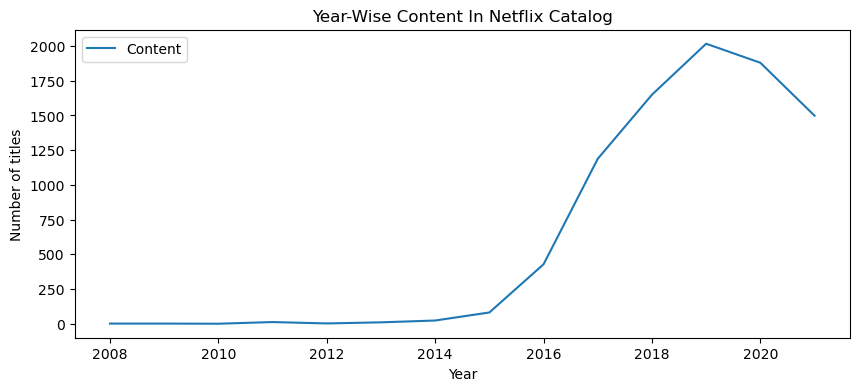

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(year_added_count.index, year_added_count.values, label="Content")
plt.legend()
plt.xlabel("Year")
plt.ylabel("Number of titles")
plt.title("Year-Wise Content In Netflix Catalog")
plt.show()

#### Conclusion : The number of titles available on Netflix increased steadily over the years and reached its peak around 2020. This trend reflects Netflix's rapid content expansion and increasing investment in content acquisition and production during that period.

## Q6 : Has released content increased over time?

In [18]:
yearly_released_content_count = df["release_year"].value_counts().sort_index()
yearly_released_content_count.head()

release_year
1925    1
1942    2
1943    3
1944    3
1945    4
Name: count, dtype: int64

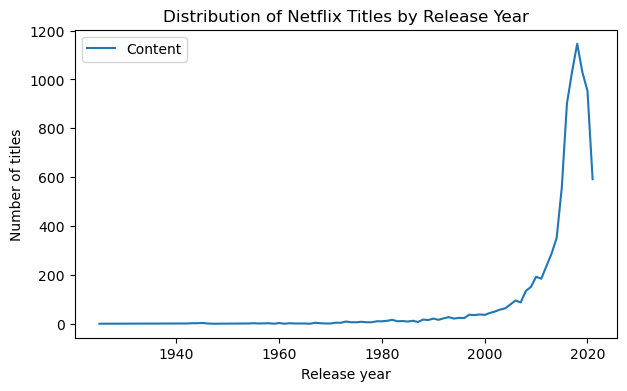

In [19]:
plt.figure(figsize=(7, 4))
plt.plot(yearly_released_content_count.index, yearly_released_content_count.values, label="Content")
plt.legend()
plt.xlabel("Release year")
plt.ylabel("Number of titles")
plt.title("Distribution of Netflix Titles by Release Year")
plt.show()

#### Conclusion : Released content increased steadily over time, with the most rapid growth occurring between 2010 and 2020. The peak around 2019–2020 suggests a period of significant catalog expansion. 
#### Any decline after this period may be influenced by the dataset's coverage ending in 2021 rather than an actual decrease in content production.

## Q7 : Are movies and tv shows growing at the same rate?

In [20]:
yearly_content = df.groupby(["release_year", "type"])["type"].count()
yearly_content = yearly_content.unstack()
yearly_content.head()

type,Movie,TV Show
release_year,,
1925,NaN,1.0
1942,2.0,NaN
1943,3.0,NaN
1944,3.0,NaN
1945,3.0,1.0


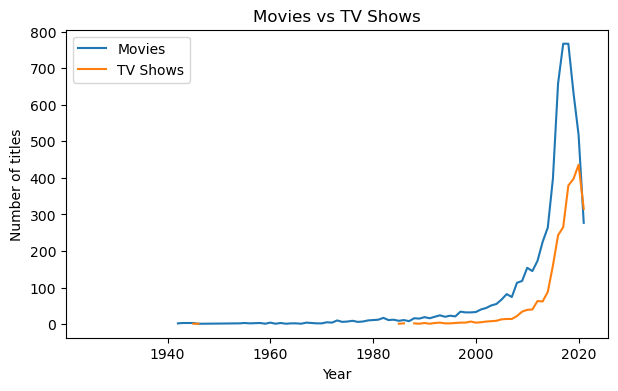

In [21]:
plt.figure(figsize=(7, 4))
plt.plot(yearly_content.index, yearly_content["Movie"], label="Movies")
plt.plot(yearly_content.index, yearly_content["TV Show"], label="TV Shows")
plt.legend()
plt.title("Movies vs TV Shows")
plt.xlabel("Year")
plt.ylabel("Number of titles")
plt.show()

#### Conclusion : Movies and TV Shows both increased significantly over time. However, Movies grew more rapidly and maintained a larger presence throughout the period analyzed.
#### The dataset shows fewer titles after 2020, which may be influenced by the dataset's coverage ending in 2021

## Q8 : What genre appears more frequently?

In [22]:
df["listed_in"] = df["listed_in"].apply(lambda x : x.split(','))
df["listed_in"] = df["listed_in"].apply(lambda x : [genre.strip() for genre in x])

In [23]:
genre_df = df.explode("listed_in")
genre_df[["show_id", "title", "listed_in"]].head()

,show_id,title,listed_in
0,s1,Dick Johnson Is Dead,Documentaries
1,s2,Blood & Water,International TV Shows
1,s2,Blood & Water,TV Dramas
1,s2,Blood & Water,TV Mysteries
2,s3,Ganglands,Crime TV Shows


In [24]:
genre_count = genre_df["listed_in"].value_counts()
genre_count.head()

listed_in
International Movies      2752
Dramas                    2427
Comedies                  1674
International TV Shows    1350
Documentaries              869
Name: count, dtype: int64

#### Conclusion : International Movies, Dramas, and Comedies are among the most common genres on Netflix. This suggests that the platform prioritizes content categories with broad global appeal and seeks to serve diverse audience preferences.

## Q9 : Does netflix offers more documentaries or dramas?

In [25]:
# genre_count - used earlier
genre_count[["Documentaries", "Dramas"]]

listed_in
Documentaries     869
Dramas           2427
Name: count, dtype: int64

#### Conclusion : Drama content significantly outnumbers documentaries in the Netflix catalog. This indicates that Netflix places a greater emphasis on entertainment-focused programming while still maintaining a substantial collection of documentary content for viewers interested in educational and informational topics.

## Q10 : Who are the top actors/actresses?

In [26]:
df["cast"] = df["cast"].apply(lambda x : x.split(','))
df["cast"] = df["cast"].apply(lambda x : [cast.strip() for cast in x])

In [27]:
cast_df = df.explode("cast")
cast_df = cast_df[cast_df["cast"] != "unknown"]

In [28]:
cast_count = cast_df["cast"].value_counts()
cast_count.head()

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Takahiro Sakurai    32
Naseeruddin Shah    32
Name: count, dtype: int64

#### Conclusion : A small group of actors appears repeatedly across Netflix titles, indicating their strong presence within the platform's catalog. Frequent appearances of these actors may contribute to audience familiarity and content discoverability.
#### The top 3 actors/actresses are : | 1. Anupam kher | 2. Shahrukh Khan | 3. Julie Tejwani | 

## Q10 : Who are the top directors?

In [29]:
df["director"] = df["director"].apply(lambda x : x.split(','))
df["director"] = df["director"].apply(lambda x : [director.strip() for director in x])

In [30]:
director_df = df.explode("director")
director_df = director_df[director_df["director"] != "unknown"]

In [31]:
director_count = director_df["director"].value_counts()
director_count.head()

director
Rajiv Chilaka    22
Jan Suter        21
Raúl Campos      19
Marcus Raboy     16
Suhas Kadav      16
Name: count, dtype: int64

#### Conclusion : Certain directors are associated with a large number of titles on Netflix, highlighting their significant contribution to the platform's content library. This pattern suggests long-term collaborations and consistent content production from a select group of creators.
#### The top 3 directors are : | 1. Rajiv Chilaka | 2. Jan Suter | 3. Raúl Campos | 

## Visualizations

### 1. Top Countries

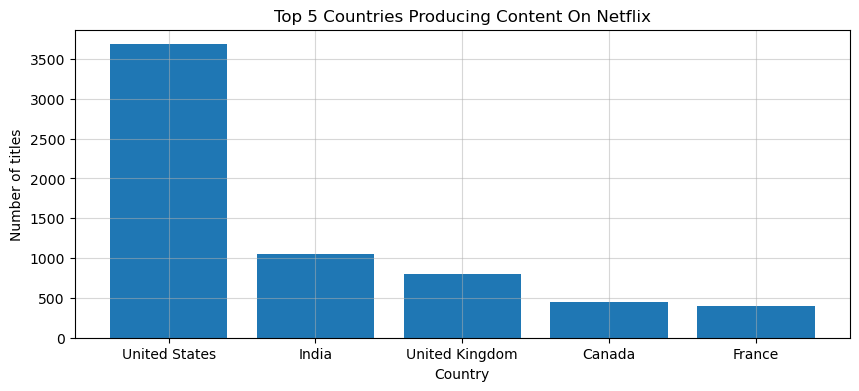

In [32]:
# country_count - used earlier
plt.figure(figsize=(10, 4))
plt.bar(country_count.index[:5], country_count.values[:5])
plt.grid(True, alpha=0.5)
plt.xlabel("Country")
plt.ylabel("Number of titles")
plt.title("Top 5 Countries Producing Content On Netflix")
plt.show()

### 2. Top Genres

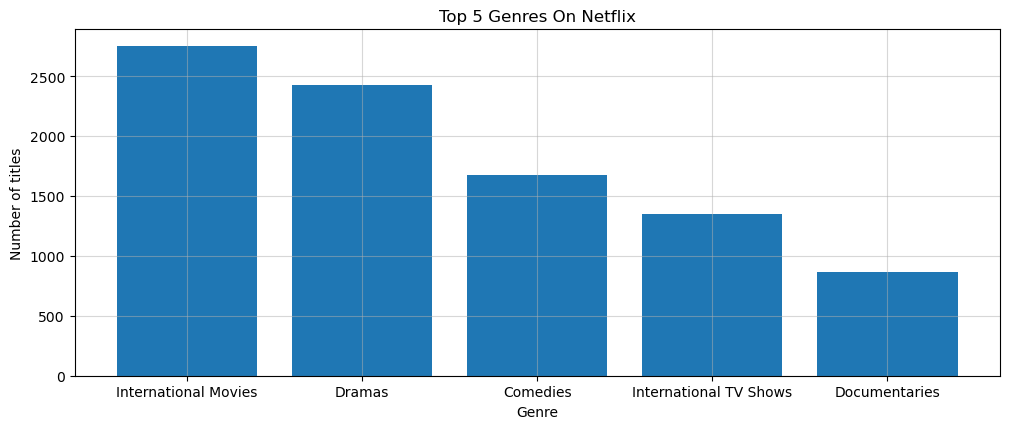

In [33]:
# genre_count - used earlier
plt.figure(figsize=(10, 4))
plt.bar(genre_count.index[:5], genre_count.values[:5])
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.xlabel("Genre")
plt.ylabel("Number of titles")
plt.title("Top 5 Genres On Netflix")
plt.show()

### 3. Rating Distribution

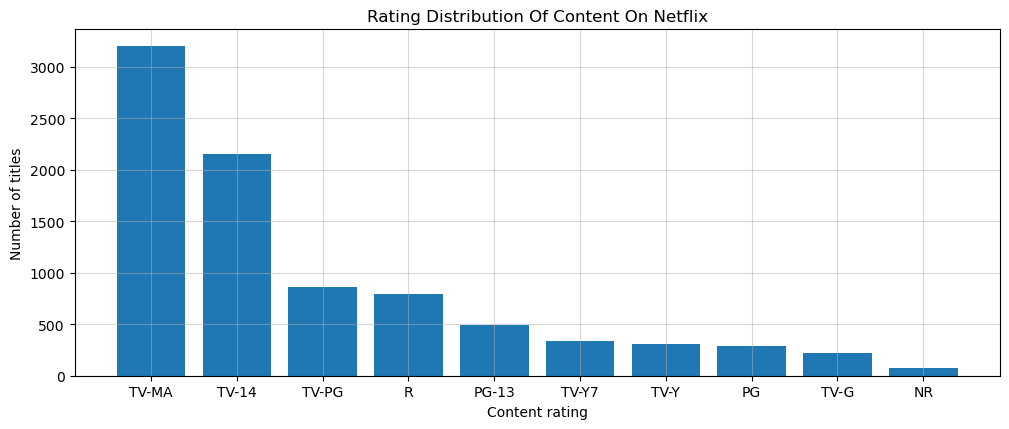

In [34]:
# rating_count - used earlier
plt.figure(figsize=(10, 4))
plt.bar(rating_count.index[:10], rating_count.values[:10])
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.xlabel("Content rating")
plt.ylabel("Number of titles")
plt.title("Rating Distribution Of Content On Netflix")
plt.show()

### 4. Top Actors

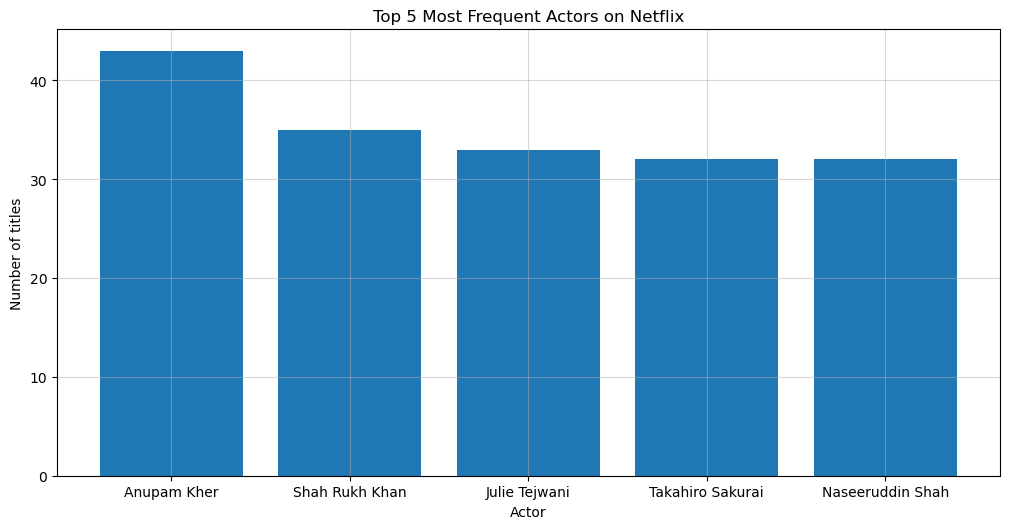

In [35]:
# cast_count - used earlier
plt.figure(figsize=(10, 5))
plt.bar(cast_count.index[:5], cast_count.values[:5])
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.xlabel("Actor")
plt.ylabel("Number of titles")
plt.title("Top 5 Most Frequent Actors on Netflix")
plt.show()

### 5. Top Directors

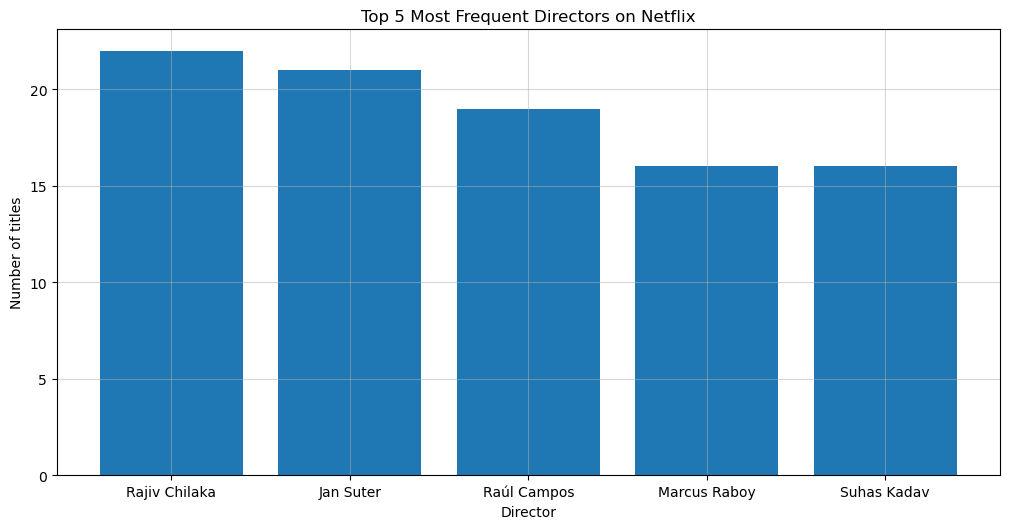

In [36]:
# director_count - used earlier
plt.figure(figsize=(10, 5))
plt.bar(director_count.index[:5], director_count.values[:5])
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.xlabel("Director")
plt.ylabel("Number of titles")
plt.title("Top 5 Most Frequent Directors on Netflix")
plt.show()

### Key Findings
- Movies dominate Netflix's content catalog and significantly outnumber TV Shows.
- The United States is the largest contributor of content, followed by countries such as India.
- TV-MA is the most common content rating, indicating a strong focus on mature audiences.
- Netflix's content library expanded rapidly over time, particularly during the 2020s.
- Movies and TV Shows both experienced growth, but Movies grew at a faster rate and remained the dominant     content type.
- International Movies, Dramas, and Comedies are among the most common genres on the platform.
- Drama content is substantially more prevalent than documentaries.
- A small number of actors and directors appear frequently across Netflix titles, highlighting their          significant contribution to the platform's catalog.

### Final Conclusion

This project analyzed Netflix's content catalog to understand content distribution, genre preferences, audience targeting, and growth trends. The analysis revealed that Netflix's library is heavily dominated by movies, with the United States and India serving as major content contributors. The platform primarily targets mature audiences through a large collection of TV-MA content while maintaining a diverse catalog across multiple genres and regions. The findings also show significant content expansion over time, particularly during the 2020s, reflecting Netflix's growth as a global streaming platform. Overall, Netflix's catalog demonstrates a strong emphasis on content diversity, global reach, and audience engagement.